# Olympic Games Data Analysis

## 1. Project Overview

This project analyzes historical Olympic Games data to identify
trends in athletes, countries, sports, and medal performance.

## 2. Research Questions

- On average, does the host country win more medals than the non-host countries?
- Do rich countries win more medals than poor countries?

In [ ]:
import pandas as pd
import sqldf
from sklearn.linear_model import LinearRegression


## 3. Data

The analysis uses three datasets:

- athlete_events.csv
- noc_regions.csv
- olympic_hosts.csv

The athlete_events.csv and noc_regions.csv were downloaded from the Coursera SQL for Data Science, while I made the olympic_hosts.csv file to make some SQL queries easier.

In [43]:
df = pd.read_csv('C:/Users/odhayaa/SQL Capstone/athlete_events.csv')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [45]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 4. Exploratory Data Analysis with Visualizations

<Axes: ylabel='Frequency'>

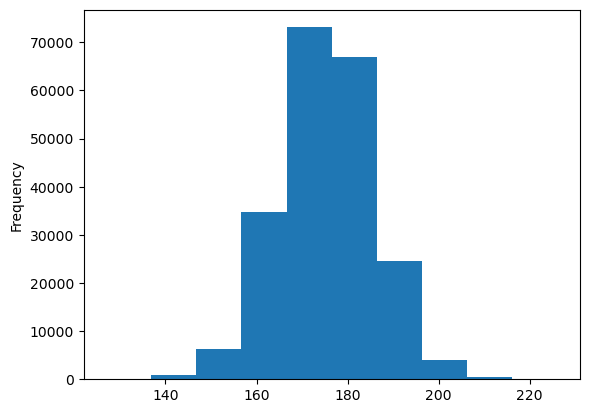

In [46]:
weight = df.iloc[:, 4] # Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc
weight.plot.hist()

<Axes: ylabel='Frequency'>

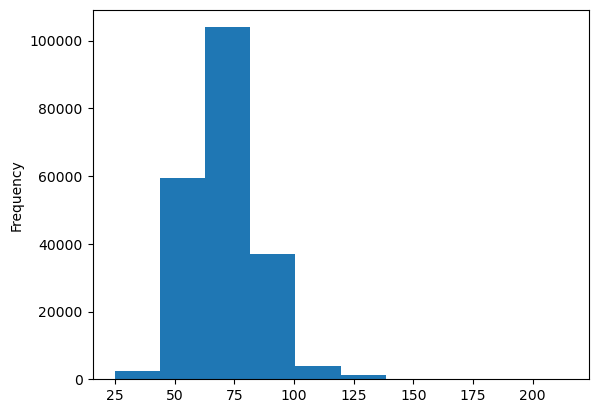

In [47]:
height = df.iloc[:, 5] # Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc
height.plot.hist()

In [ ]:
sqldf("SELECT * FROM df")

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,None
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",None
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",None
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,None


In [49]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [50]:
sqldf("SELECT DISTINCT City FROM df")

,City
0,Barcelona
1,London
2,Antwerpen
3,Paris
4,Calgary
5,Albertville
6,Lillehammer
7,Los Angeles
8,Salt Lake City
9,Helsinki


In [51]:
df1 = pd.read_csv("C:/Users/odhayaa/SQL Capstone/olympic_hosts.csv")
sqldf("SELECT * FROM df1")

,City,Country,Host_Year
0,Barcelona,Spain,1992
1,London,Great Britain,1908
2,London,Great Britain,1948
3,London,Great Britain,2012
4,Antwerpen,Belgium,1920
5,Paris,France,1900
6,Paris,France,1924
7,Calgary,Canada,1988
8,Albertville,France,1992
9,Lillehammer,Norway,1994


In [52]:
df2 = sqldf("SELECT df.ID, df.Name, df.Sex, df.Age, df.Height, df.Weight, df.Team, df.NOC, df.Games, df.Year, df.Season, df.City, df1.Country, df.Sport, df.Event, df.Medal " \
"FROM df LEFT JOIN df1 ON df.city = df1.city AND df.year = df1.host_year")
df2

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Country,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Spain,Basketball,Basketball Men's Basketball,None
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Great Britain,Judo,Judo Men's Extra-Lightweight,None
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Belgium,Football,Football Men's Football,None
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,France,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Canada,Speed Skating,Speed Skating Women's 500 metres,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Austria,Luge,Luge Mixed (Men)'s Doubles,None
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,None,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",None
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,None,Ski Jumping,"Ski Jumping Men's Large Hill, Team",None
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Japan,Bobsleigh,Bobsleigh Men's Four,None


## 5. Key Findings

I want to determine if the host country does better compared to other countries on average. To do this, I can find the number of medals won by the host country vs the average number of medals won by the other countries for each year.


In [53]:
df3 = sqldf("SELECT df2.Games, df2.Country, COUNT(df2.Medal) FROM df2 WHERE Team Like Country GROUP BY Games")
df3

,Games,Country,COUNT(df2.Medal)
0,1896 Summer,Greece,44
1,1900 Summer,France,75
2,1904 Summer,United States,199
3,1906 Summer,Greece,28
4,1908 Summer,Great Britain,167
5,1920 Summer,Belgium,177
6,1924 Summer,France,101
7,1924 Winter,France,8
8,1928 Summer,Netherlands,51
9,1928 Winter,Switzerland,12


In [54]:
df3.describe()

,COUNT(df2.Medal)
count,46.000000
mean,70.978261
std,78.792975
min,0.000000
25%,14.500000
50%,39.500000
75%,83.750000
max,352.000000


<Axes: >

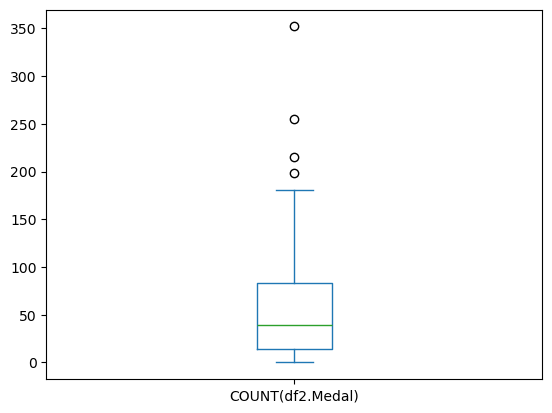

In [55]:
df3.plot.box()

In [56]:
df4 = sqldf("SELECT df2.Games, df2.Country, COUNT(df2.Medal)/COUNT(DISTINCT(df2.Team)) FROM df2 WHERE Team NOT LIKE Country GROUP BY Games, Year, Season")
df4

,Games,Country,COUNT(df2.Medal)/COUNT(DISTINCT(df2.Team))
0,1896 Summer,Greece,5
1,1900 Summer,France,2
2,1904 Summer,United States,3
3,1906 Summer,Greece,8
4,1908 Summer,Great Britain,9
5,1920 Summer,Belgium,15
6,1924 Summer,France,8
7,1924 Winter,France,4
8,1928 Summer,Netherlands,10
9,1928 Winter,Switzerland,1


In [57]:
df4.describe()

,COUNT(df2.Medal)/COUNT(DISTINCT(df2.Team))
count,49.000000
mean,5.408163
std,3.593503
min,1.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,17.000000


<Axes: >

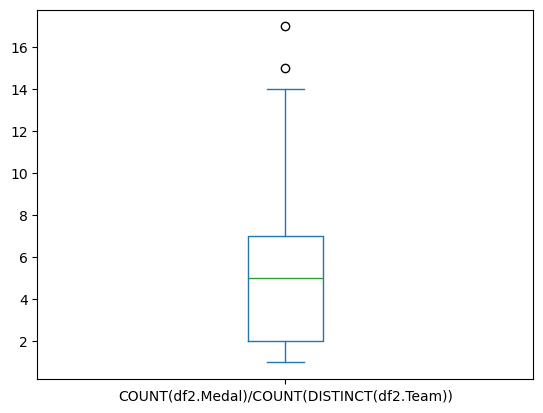

In [58]:
df4.plot.box()

On average, the host country won 70.98 medals. The average of the average of the medal count for the non-host countries was 5.4. The standard deviations were 78.79 and 3.59 respectively. The host country tends to win more on average and the deviation from the mean is much more than the non-host countries for each year.

In [59]:
df5 = sqldf("SELECT Games, NOC, COUNT(df.Medal), CASE WHEN NOC IN ('AND', 'AUS', 'AUT', 'BEL', 'CAN', 'CRO', 'CYP', 'CZE', 'DEN', 'EST', 'FIN', 'FRA', 'FRG', 'GER', 'GRE', 'HKG', 'ISL', 'IRL', 'ISR', 'ITA', 'JPN', 'KOR', 'LAT', 'LTU', 'LUX', 'MLT', 'NED', 'NZL', 'NOR', 'POR', 'PUR', 'SMR', 'SIN', 'SVK', 'SLO', 'ESP', 'SWE', 'SUI', 'TPE', 'GBR', 'USA') THEN 'Rich'" \
" ELSE 'Poor' END Wealth FROM df WHERE Year >= 1992 GROUP BY NOC, Games ORDER BY COUNT(df.Medal) DESC")
df5

# https://stackoverflow.com/questions/2004147/sql-case-column-when-in-case1-case2-then-oops-end

,Games,NOC,COUNT(df.Medal),Wealth
0,2008 Summer,USA,317,Rich
1,2016 Summer,USA,264,Rich
2,2004 Summer,USA,263,Rich
3,1996 Summer,USA,259,Rich
4,2012 Summer,USA,248,Rich
...,...,...,...,...
1908,1996 Summer,ZIM,0,Poor
1909,2000 Summer,ZIM,0,Poor
1910,2012 Summer,ZIM,0,Poor
1911,2014 Winter,ZIM,0,Poor


In [60]:
df6 = sqldf("SELECT * FROM df5 WHERE Wealth = 'Rich'")
df6

,Games,NOC,COUNT(df.Medal),Wealth
0,2008 Summer,USA,317,Rich
1,2016 Summer,USA,264,Rich
2,2004 Summer,USA,263,Rich
3,1996 Summer,USA,259,Rich
4,2012 Summer,USA,248,Rich
...,...,...,...,...
517,1998 Winter,TPE,0,Rich
518,2002 Winter,TPE,0,Rich
519,2006 Winter,TPE,0,Rich
520,2010 Winter,TPE,0,Rich


In [61]:
df6.describe()

,COUNT(df.Medal)
count,522.000000
mean,21.306513
std,41.000654
min,0.000000
25%,0.000000
50%,4.000000
75%,24.000000
max,317.000000


<Axes: >

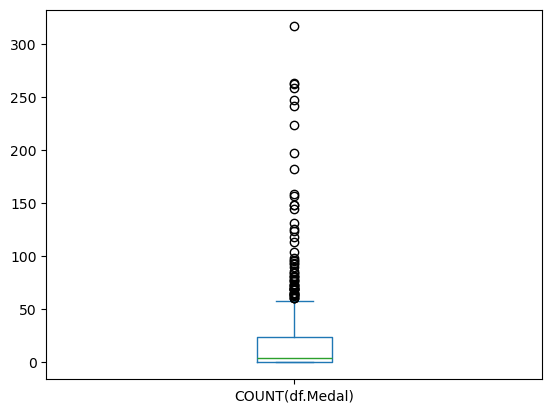

In [62]:
df6.plot.box()

In [63]:
df7 = sqldf("SELECT * FROM df5 WHERE Wealth = 'Poor'")
df7

,Games,NOC,COUNT(df.Medal),Wealth
0,1992 Summer,EUN,220,Poor
1,2004 Summer,RUS,189,Poor
2,2000 Summer,RUS,187,Poor
3,2008 Summer,CHN,184,Poor
4,2008 Summer,RUS,142,Poor
...,...,...,...,...
1386,1996 Summer,ZIM,0,Poor
1387,2000 Summer,ZIM,0,Poor
1388,2012 Summer,ZIM,0,Poor
1389,2014 Winter,ZIM,0,Poor


In [64]:
df7.describe()

,COUNT(df.Medal)
count,1391.000000
mean,4.068296
std,16.369135
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,220.000000


<Axes: >

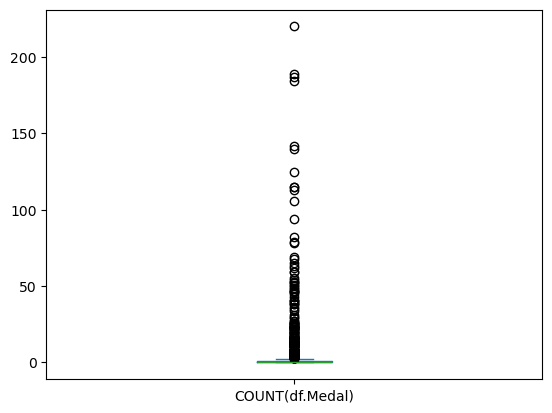

In [65]:
df7.plot.box()

The way I defined rich was using list of advanced economics from the IMF: https://www.imf.org/en/publications/weo/weo-database/2023/april/groups-and-aggregates. I also decided to only look at results from 1992 onward because there were a lot of countries before then that don't exist anymore, like the Soviet Union and Yugoslavia. On average, the rich countries won 21.31 medals while the poor countries won 4.07. The standard deviations were 41 and 16.37 respectively. The max medals won by the rich countries was the US in the Summer 2008 Olympics with 317, while the max for the poor countries was Russia at the 1992 Olympics with 220.

## 6. Additional Question

- How does height, weight, and age affect athletes' results?

In [66]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [69]:
df.corr(numeric_only=True)

,ID,Age,Height,Weight,Year
ID,1.000000,-0.003631,-0.011141,-0.009176,0.011885
Age,-0.003631,1.000000,0.138246,0.212069,-0.115137
Height,-0.011141,0.138246,1.000000,0.796213,0.047578
Weight,-0.009176,0.212069,0.796213,1.000000,0.019095
Year,0.011885,-0.115137,0.047578,0.019095,1.000000


In [70]:
df.height = sqldf("SELECT height FROM df WHERE height IS NOT NULL AND weight IS NOT NULL GROUP BY Name")
df.height
df.weight = sqldf("SELECT weight FROM df WHERE weight IS NOT NULL AND height IS NOT NULL GROUP BY Name")
df.weight

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\2352684944.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.height = sqldf("SELECT height FROM df WHERE height IS NOT NULL AND weight IS NOT NULL GROUP BY Name")
C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\2352684944.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.weight = sqldf("SELECT weight FROM df WHERE weight IS NOT NULL AND height IS NOT NULL GROUP BY Name")


,Weight
0,58.0
1,47.0
2,63.0
3,80.0
4,60.0
...,...
99036,70.0
99037,47.0
99038,72.0
99039,74.0


In [71]:
reg = LinearRegression().fit(X = df.height, y = df.weight)
reg.score(df.height, df.weight)

0.6008015752137149

<Axes: xlabel='Height', ylabel='Weight'>

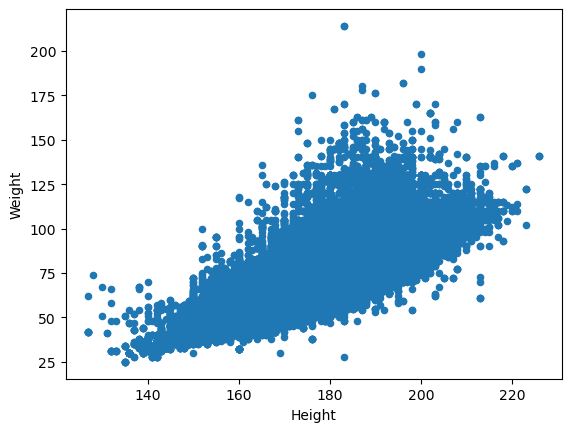

In [72]:
scatterplot = df.plot.scatter(4, 5)
scatterplot

In [73]:
df.menheight = sqldf("SELECT height FROM df WHERE height IS NOT NULL AND Sex = 'M' AND weight IS NOT NULL GROUP BY Name")
df.menheight
df.menweight = sqldf("SELECT weight FROM df WHERE weight IS NOT NULL AND Sex = 'M' AND height IS NOT NULL GROUP BY Name")
df.menweight

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\3952810705.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.menheight = sqldf("SELECT height FROM df WHERE height IS NOT NULL AND Sex = 'M' AND weight IS NOT NULL GROUP BY Name")
C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\3952810705.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.menweight = sqldf("SELECT weight FROM df WHERE weight IS NOT NULL AND Sex = 'M' AND height IS NOT NULL GROUP BY Name")


,Weight
0,63.0
1,80.0
2,60.0
3,70.0
4,70.0
...,...
69409,58.0
69410,72.0
69411,72.0
69412,74.0


In [74]:
reg = LinearRegression().fit(X = df.menheight, y = df.menweight)
reg.score(df.menheight, df.menweight)

0.5137218131770755

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\3912165016.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.menhw = sqldf("SELECT height, weight FROM df WHERE height IS NOT NULL AND Sex = 'M' AND weight IS NOT NULL GROUP BY Name")


<Axes: xlabel='Height', ylabel='Weight'>

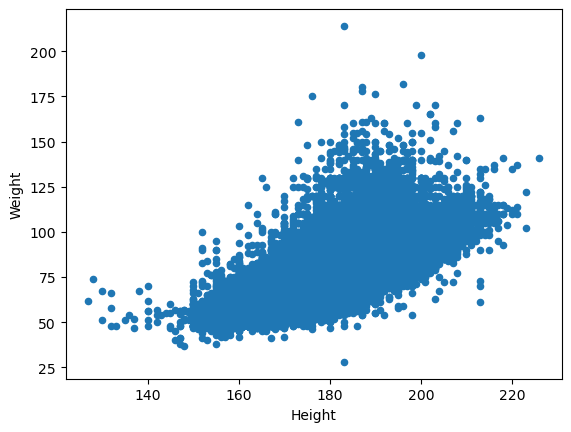

In [75]:
df.menhw = sqldf("SELECT height, weight FROM df WHERE height IS NOT NULL AND Sex = 'M' AND weight IS NOT NULL GROUP BY Name")
df.menhw
menhwplot = df.menhw.plot.scatter(0,1)
menhwplot

In [76]:
df.womenheight = sqldf("SELECT height FROM df WHERE height IS NOT NULL AND Sex = 'F' AND weight IS NOT NULL GROUP BY Name")
df.womenheight
df.womenweight = sqldf("SELECT weight FROM df WHERE weight IS NOT NULL AND Sex = 'F' AND height IS NOT NULL GROUP BY Name")
df.womenweight

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\2896879979.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.womenheight = sqldf("SELECT height FROM df WHERE height IS NOT NULL AND Sex = 'F' AND weight IS NOT NULL GROUP BY Name")
C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\2896879979.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.womenweight = sqldf("SELECT weight FROM df WHERE weight IS NOT NULL AND Sex = 'F' AND height IS NOT NULL GROUP BY Name")


,Weight
0,58.0
1,47.0
2,53.0
3,64.0
4,85.0
...,...
29675,50.0
29676,50.0
29677,60.0
29678,70.0


In [77]:
reg = LinearRegression().fit(X = df.womenheight, y = df.womenweight)
reg.score(df.womenheight, df.womenweight)

0.4864790913917052

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\1119240549.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.womenhw = sqldf("SELECT height, weight FROM df WHERE height IS NOT NULL AND Sex = 'F' AND weight IS NOT NULL GROUP BY Name")


<Axes: xlabel='Height', ylabel='Weight'>

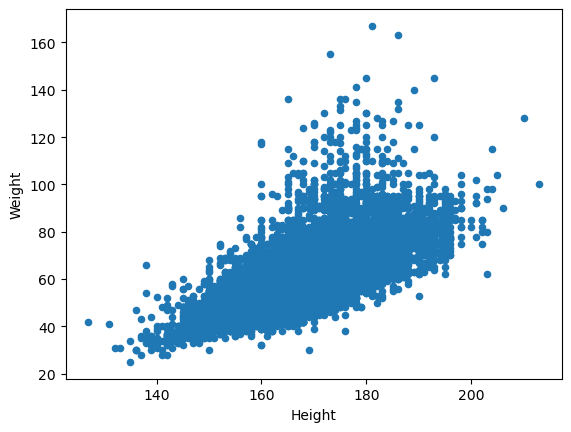

In [78]:
df.womenhw = sqldf("SELECT height, weight FROM df WHERE height IS NOT NULL AND Sex = 'F' AND weight IS NOT NULL GROUP BY Name")
df.womenhw
womenhwplot = df.womenhw.plot.scatter(0,1)
womenhwplot

Dive Deeper

1. I used df.corr() to make a correlation matrix for all of the numerical data. The only correlation coefficient that wasn't near 0 was the relationship for height and weight, which was .796. This shows a strong corrleation between height and weight while the other relationships have no correlation.
2. I wanted to look further into this, so I made a query to get the heights and weights of all of the athletes. I used LinearRegression().fit() to make a linear regression for relating height and weight. Then I used .score() to get the coefficient of determination, which is .601. This shows that linear regression captures the variance of the data well. https://en.wikipedia.org/wiki/Coefficient_of_determination#Interpretation. I split the data by sex to see what the scores are for men and women, and I got .514 and .486. These coefficients are still high, but linear regression doesn't capture the data as well.

<Axes: ylabel='Frequency'>

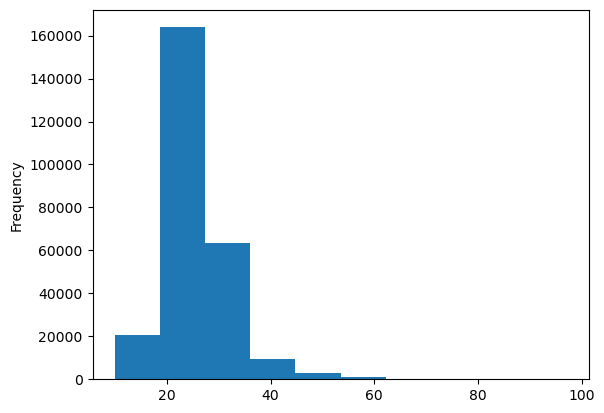

In [79]:
age = df.iloc[:, 3] # Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc
age.plot.hist()

In [80]:
df.youngathletes = sqldf("SELECT name, age, COUNT(df.Medal) FROM df WHERE age <= 25 GROUP BY name ORDER BY COUNT(df.Medal) DESC")
df.youngathletes

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\3521380837.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.youngathletes = sqldf("SELECT name, age, COUNT(df.Medal) FROM df WHERE age <= 25 GROUP BY name ORDER BY COUNT(df.Medal) DESC")


,Name,Age,COUNT(df.Medal)
0,"Michael Fred Phelps, II",15.0,16
1,Larysa Semenivna Latynina (Diriy-),21.0,12
2,Aleksey Yuryevich Nemov,20.0,12
3,Natalie Anne Coughlin (-Hall),21.0,11
4,Mark Andrew Spitz,18.0,11
...,...,...,...
86583,Th Ngn Thng,19.0,0
86584,Th Anh,20.0,0
86585,Luis ngel Fernando de los Santos Grossi,23.0,0
86586,Eleonora Margarida Josephina Scmitt,16.0,0


In [81]:
df.youngathletes.describe()

,Age,COUNT(df.Medal)
count,86588.000000,86588.000000
mean,21.551601,0.243255
std,2.475427,0.587493
min,10.000000,0.000000
25%,20.000000,0.000000
50%,22.000000,0.000000
75%,24.000000,0.000000
max,25.000000,16.000000


In [82]:
df.oldathletes = sqldf("SELECT name, age, COUNT(df.Medal) FROM df WHERE age > 25 GROUP BY name ORDER BY COUNT(df.Medal) DESC")
df.oldathletes

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\2375720996.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.oldathletes = sqldf("SELECT name, age, COUNT(df.Medal) FROM df WHERE age > 25 GROUP BY name ORDER BY COUNT(df.Medal) DESC")


,Name,Age,COUNT(df.Medal)
0,"Michael Fred Phelps, II",27.0,12
1,Edoardo Mangiarotti,29.0,12
2,Viktor Ivanovych Chukarin,30.0,11
3,Ole Einar Bjrndalen,28.0,11
4,Carl Townsend Osburn,28.0,11
...,...,...,...
61814,Aa Bela Joaquim,29.0,0
61815,"A. J. Tyronne Benildus ""Benny"" Fernando",27.0,0
61816,A. Aanantha Sambu Mayavo,26.0,0
61817,Luis ngel Fernando de los Santos Grossi,27.0,0


In [83]:
df.oldathletes.describe()

,Age,COUNT(df.Medal)
count,61819.000000,61819.000000
mean,29.641033,0.290979
std,5.050855,0.669828
min,26.000000,0.000000
25%,27.000000,0.000000
50%,28.000000,0.000000
75%,30.000000,0.000000
max,97.000000,12.000000


In [86]:
df.medalists = sqldf("SELECT * FROM df WHERE Medal IS NOT NULL GROUP BY Name")
df.medalists

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\2064414660.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.medalists = sqldf("SELECT * FROM df WHERE Medal IS NOT NULL GROUP BY Name")


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,2316,A. Albert,M,NaN,NaN,NaN,Union des Socits Franais de Sports Athletiques,FRA,1900 Summer,1900,Summer,Paris,Rugby,Rugby Men's Rugby,Gold
1,30274,A. Dubois,M,NaN,NaN,NaN,Gitana-2,FRA,1900 Summer,1900,Summer,Paris,Sailing,Sailing Mixed 3-10 Ton,Bronze
2,129771,"A. Joshua ""Josh"" West",M,31.0,207.0,105.0,Great Britain,GBR,2008 Summer,2008,Summer,Beijing,Rowing,Rowing Men's Coxed Eights,Silver
3,67346,A. Lawry,M,NaN,NaN,NaN,Cornwall,GBR,1908 Summer,1908,Summer,London,Rugby,Rugby Men's Rugby,Silver
4,131535,A. M. Woods,M,NaN,NaN,NaN,St. Louis Amateur Athletic Association,USA,1904 Summer,1904,Summer,St. Louis,Lacrosse,Lacrosse Men's Lacrosse,Silver
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28197,98532,va Rakusz,F,19.0,176.0,69.0,Hungary,HUN,1980 Summer,1980,Summer,Moskva,Canoeing,"Canoeing Women's Kayak Doubles, 500 metres",Bronze
28198,101041,va Risztov,F,26.0,173.0,72.0,Hungary,HUN,2012 Summer,2012,Summer,London,Swimming,Swimming Women's 10 kilometres Open Water,Gold
28199,117453,va Szkely (-Gyarmati),F,25.0,NaN,NaN,Hungary,HUN,1952 Summer,1952,Summer,Helsinki,Swimming,Swimming Women's 200 metres Breaststroke,Gold
28200,7482,ver Maximiliano David Banega,M,20.0,175.0,73.0,Argentina,ARG,2008 Summer,2008,Summer,Beijing,Football,Football Men's Football,Gold


In [87]:
df.athletes = sqldf("SELECT * FROM df GROUP BY Name")
df.athletes

C:\Users\odhayaa\AppData\Local\Temp\ipykernel_14608\636544298.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.athletes = sqldf("SELECT * FROM df GROUP BY Name")


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,869,"Gabrielle Marie ""Gabby"" Adcock (White-)",F,25.0,167.0,NaN,Great Britain,GBR,2016 Summer,2016,Summer,Rio de Janeiro,Badminton,Badminton Mixed Doubles,None
1,107953,Eleonora Margarida Josephina Scmitt,F,16.0,NaN,NaN,Brazil,BRA,1948 Summer,1948,Summer,London,Swimming,Swimming Women's 100 metres Freestyle,None
2,46661,Jean Hauptmanns,M,26.0,NaN,NaN,Germany,GER,1912 Summer,1912,Summer,Stockholm,Wrestling,"Wrestling Men's Heavyweight, Greco-Roman",None
3,26388,Luis ngel Fernando de los Santos Grossi,M,23.0,NaN,NaN,Uruguay,URU,1948 Summer,1948,Summer,London,Cycling,"Cycling Men's Team Pursuit, 4,000 metres",None
4,29842,Th Anh,F,20.0,165.0,58.0,Vietnam,VIE,2016 Summer,2016,Summer,Rio de Janeiro,Fencing,"Fencing Women's Foil, Individual",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134727,60685,zge Krdar emberci,F,27.0,183.0,70.0,Turkey,TUR,2012 Summer,2012,Summer,London,Volleyball,Volleyball Women's Volleyball,None
134728,58232,zlem Kaya,F,22.0,165.0,47.0,Turkey,TUR,2012 Summer,2012,Summer,London,Athletics,"Athletics Women's 3,000 metres Steeplechase",None
134729,40545,zman Graud,M,33.0,168.0,72.0,Turkey,TUR,1972 Summer,1972,Summer,Munich,Shooting,Shooting Mixed Skeet,None
134730,104222,zzet Safer,M,26.0,178.0,74.0,Turkey,TUR,2016 Summer,2016,Summer,Rio de Janeiro,Athletics,Athletics Men's 4 x 100 metres Relay,None


New Metric

1. The metric I came up with is whether an Olympic athlete won at least one medal. In total, there have been 134732 athletes that have competed in the Summer and Winter Olympics from 1896-2016. The number of athletes that won at least one medal is 28202. The rate of athletes that won medals is 28202/134732 = .209, or about 20.9%. I created this metric because it was the closest equivalent to a business metric I could think of for this dataset.

In [88]:
28202/134732

0.2093192411602292